In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dfs = [pd.read_csv(f, index_col=0) for f in FILES.values()]
for thr, df in zip(FILES.keys(), dfs):
    df["threshold"] = thr
dfs = pd.concat(dfs)

In [2]:
dfs = pd.read_csv("../results/permutation_results_20230706_13:45:00")
dfs

,file_name,bin_size,chrom,alpha_threshold,a,b,pval,num_perms,statistic
0,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.05,heterochromatin,universe,0.854146,1000,ave_degree
1,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.05,enhancer,universe,0.990010,1000,ave_degree
2,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.05,polycomb,universe,0.994006,1000,ave_degree
3,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.05,promoter,universe,0.541459,1000,ave_degree
4,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chr1,0.05,heterochromatin,enhancer,0.051948,1000,ave_degree
...,...,...,...,...,...,...,...,...,...
1915,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chrY,0.40,heterochromatin,polycomb,1.000000,1000,ave_degree
1916,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chrY,0.40,heterochromatin,promoter,0.991009,1000,ave_degree
1917,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chrY,0.40,enhancer,polycomb,0.000999,1000,ave_degree
1918,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,10000,chrY,0.40,enhancer,promoter,0.004995,1000,ave_degree


In [3]:
dfs.sort_values(["a", "b", "alpha_threshold"], inplace=True)

In [4]:
sig_column = [1 if v < 0.05 else 0 for v in dfs["pval"]]
sig_column = [-1 if v > 0.95 else e for e, v in zip(sig_column, dfs["pval"])]

In [ ]:
dfs.loc[dfs["a"] == "1_TssA", "a"] = "TssA"
dfs.loc[dfs["a"] == "7_Enh", "a"] = "Enhancer"
dfs.loc[dfs["b"] == "Bound", "b"] = "Boundary"
dfs.loc[dfs["b"] == "universe", "b"] = "Universe"

In [6]:
dfs["significance"] = sig_column
dfs["test"] = dfs["a"] + "\n vs \n" + dfs["b"]

dfs.drop(["pval", "a", "b"], axis=1, inplace=True)

In [7]:
dfs["alpha_threshold"] = dfs["alpha_threshold"].astype(str)

In [8]:
dfs["alpha_threshold"] = ["0.10" if v == "0.1" else v for v in dfs["alpha_threshold"]]

In [9]:
tests = dfs["test"].unique().tolist()

In [10]:
dfs["name"] = [fn.split("_")[2] for fn in dfs["file_name"]]

In [11]:
mult_dfs = {t: dfs[dfs["test"] == t].drop("test", axis=1) for t in tests} 

In [12]:
mult_dfs = {k: pd.pivot(v, values="significance", index="alpha_threshold", columns="chrom") for k, v in mult_dfs.items()}

In [15]:
CHR_ORDER = ["chr" + str(v) for v in range(1, 23)] + ["chrX", "chrY"]
mult_dfs = {k: v[CHR_ORDER] for k, v in mult_dfs.items()}

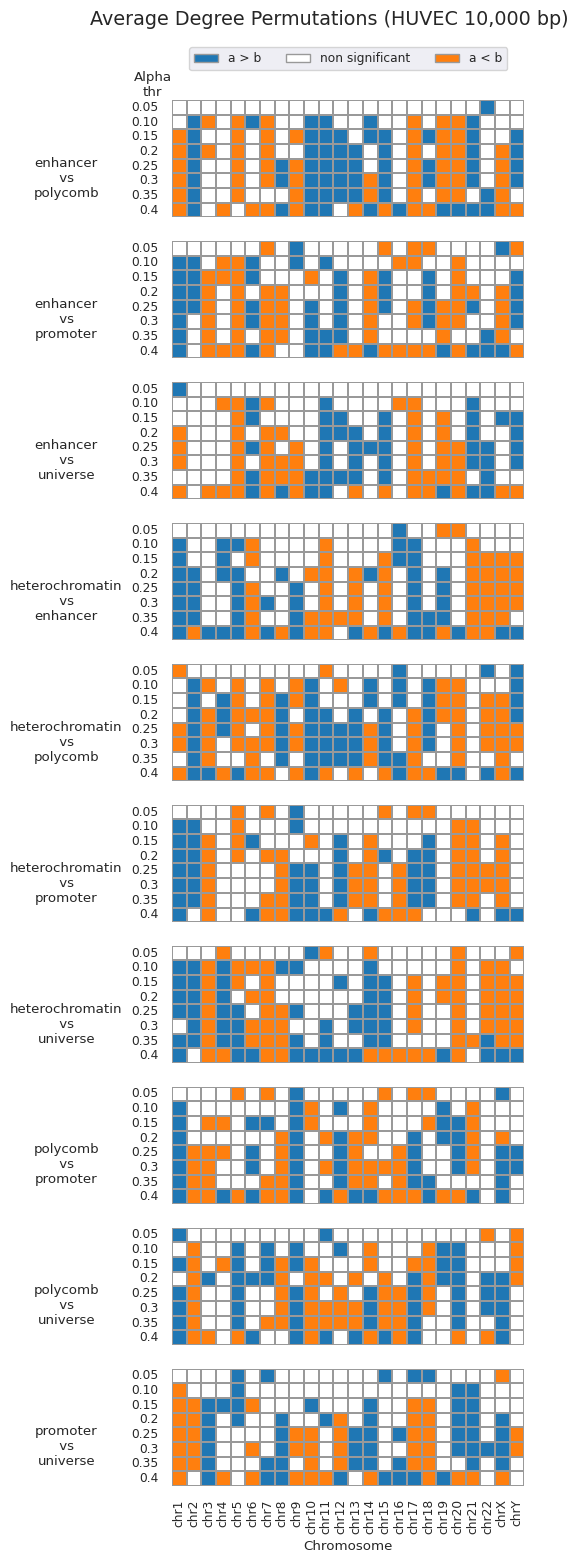

In [17]:
HEAT_PALETTE = [sns.color_palette("tab10")[0], (1,1,1), sns.color_palette("tab10")[1],]
GRAY = (0.6,0.6,0.6)
PATCHES = [
    mpatches.Patch(color=sns.color_palette("tab10")[0], label='a > b', ec=GRAY),
    mpatches.Patch(color=(1,1,1), label='non significant', ec=GRAY),
    mpatches.Patch(color=sns.color_palette("tab10")[1], label='a < b', ec=GRAY),
]

sns.set(font_scale=0.8)

fig, ax = plt.subplots(nrows=len(mult_dfs), ncols=1, figsize=(15,18))
counter = 0
for (t, d), a in zip(mult_dfs.items(), ax):
    counter += 1
    
    if counter != len(mult_dfs):
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=False,
        )
        a.set(xlabel=None)
    else:
        a = sns.heatmap(
            d, 
            cmap=HEAT_PALETTE, 
            square=True, 
            linewidth=0.01, 
            linecolor=GRAY, 
            ax=a, 
            cbar=False,
            xticklabels=True,
        )
        a.set(xlabel="Chromosome")
    
    if counter == 1:
        a.legend(handles=PATCHES, loc="upper center",bbox_to_anchor=(0.5, 1.5), ncol=3, fancybox=True)
        a.text(-1.3, -0.3, "Alpha\nthr", horizontalalignment="center")
    
    a.set_ylabel(t, rotation=0, labelpad=10)
    a.yaxis.set_label_coords(-0.30, 0.15)

fig.suptitle("Average Degree Permutations (HUVEC 10,000 bp)", y=0.93, fontsize="x-large")

plt.show()

In [ ]:
sns.color_palette("tab10")[0]

In [53]:
dfs[(dfs["a"] == "enhancer") & (dfs["b"]=="polycomb") & (dfs["chrom"]=="3")]

,file_name,alpha_threshold,bin_size,stat,num_perms,chrom,a,b,a != b,a > b,a < b
157,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.05,10000,ave_degree,1000,3,enhancer,polycomb,0.537,0.256,0.738
397,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.10,10000,ave_degree,1000,3,enhancer,polycomb,0.064,0.033,0.967
637,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.15,10000,ave_degree,1000,3,enhancer,polycomb,0.621,0.299,0.701
877,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.20,10000,ave_degree,1000,3,enhancer,polycomb,0.062,0.031,0.969
1117,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.25,10000,ave_degree,1000,3,enhancer,polycomb,0.508,0.251,0.749
1357,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.30,10000,ave_degree,1000,3,enhancer,polycomb,0.301,0.155,0.845
1597,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.35,10000,ave_degree,1000,3,enhancer,polycomb,0.334,0.166,0.834
1837,Rao_2014_HUVEC_MboI_4DNFIRMZ7QTE.mcool,0.40,10000,ave_degree,1000,3,enhancer,polycomb,0.368,0.803,0.197
